Linear Congruential Generator

$x_i = (ax_{i-1}+c)\:\text{mod}\: M, \quad u_i = \frac{x_i}{M}$

In [6]:
def lcg(seed, a, c, M, n):
    x = seed
    numbers = []

    for _ in range(n):
        x = (a * x + c) % M
        numbers.append(x / M)

    return numbers

In [7]:
u = lcg(seed=1,
        a=1103515245,
        c=12345,
        M=2**31,
        n=10000)

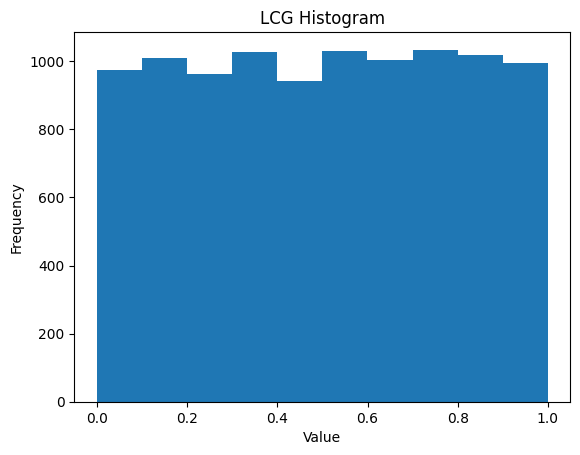

In [8]:
import matplotlib.pyplot as plt

plt.hist(u, bins=10)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("LCG Histogram")
plt.show()

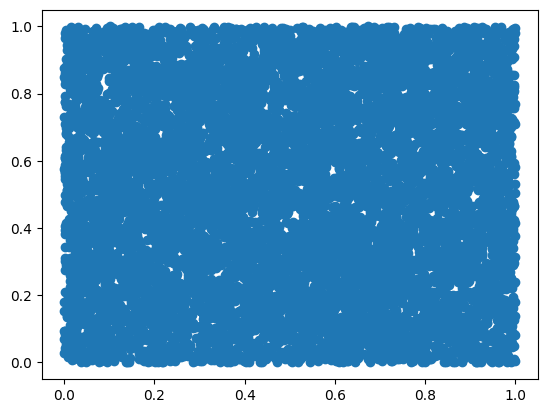

In [9]:
plt.scatter(u[:-1], u[1:])

Part 1.c - Testing different values

In [1]:
def lcg(seed, a, c, M, n):
    x = seed
    numbers = []

    for _ in range(n):
        x = (a * x + c) % M
        numbers.append(x / M)

    return numbers

In [2]:
bad = lcg(
    seed=29,
    a=5,
    c=1,
    M=16,
    n=10000
)

In [3]:
good = lcg(
    seed=29,
    a=1103515245,
    c=12345,
    M=2**31,
    n=10000
)

In [4]:
import matplotlib.pyplot as plt

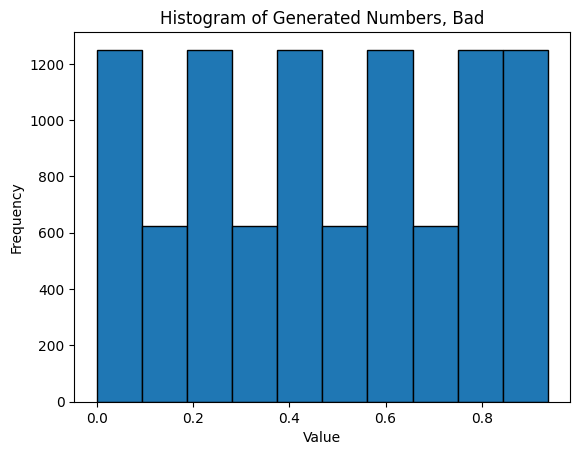

In [5]:
plt.hist(
    bad,
    bins=10,
    edgecolor="black"
)

plt.title("Histogram of Generated Numbers, Bad")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

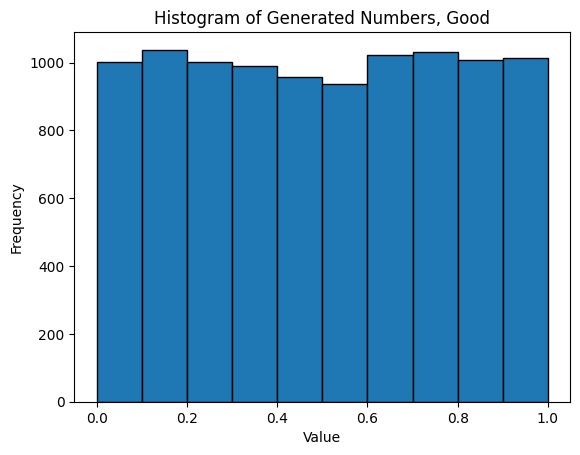

In [9]:
plt.hist(
    good,
    bins=10,
    edgecolor="black"
)

plt.title("Histogram of Generated Numbers, Good")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

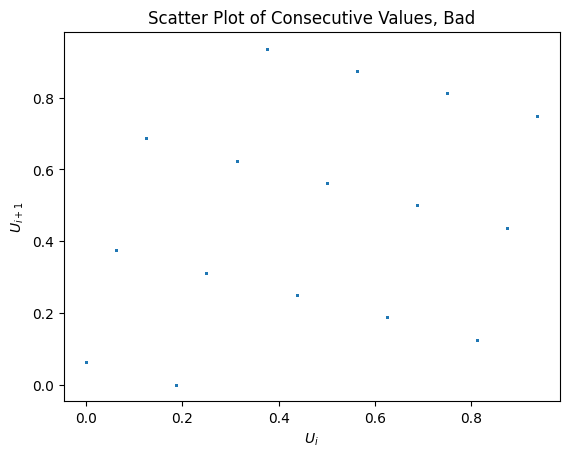

In [7]:
x = []
y = []

for i in range(len(bad)-1):
    x.append(bad[i])
    y.append(bad[i+1])

plt.scatter(
    x,
    y,
    s=1
)

plt.title("Scatter Plot of Consecutive Values, Bad")
plt.xlabel(r"$U_i$")
plt.ylabel(r"$U_{i+1}$")

plt.show()

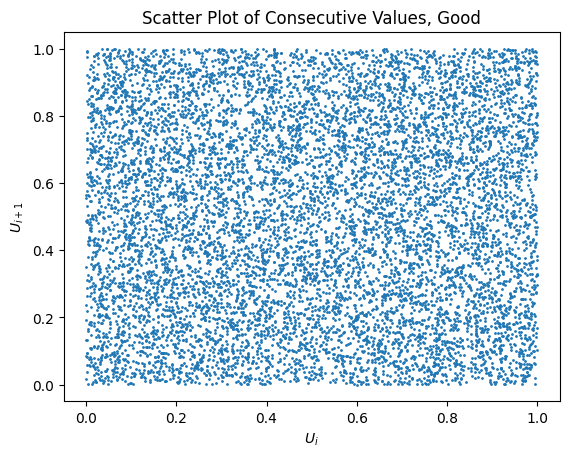

In [8]:
x = []
y = []

for i in range(len(good)-1):
    x.append(good[i])
    y.append(good[i+1])

plt.scatter(
    x,
    y,
    s=1
)

plt.title("Scatter Plot of Consecutive Values, Good")
plt.xlabel(r"$U_i$")
plt.ylabel(r"$U_{i+1}$")

plt.show()

In [13]:
def histogram(data, bins=10):

    counts = [0] * bins

    for x in data:

        index = int(x * bins)

        if index == bins:
            index = bins - 1

        counts[index] += 1

    return counts

def chi_square_uniform(data, bins=10):

    counts = histogram(data, bins)

    n = len(data)

    expected = n / bins

    chi2 = 0.0

    for observed in counts:

        diff = observed - expected

        chi2 += (
            diff * diff
            / expected
        )

    return chi2

chi2_good = chi_square_uniform(good)

chi2_bad = chi_square_uniform(bad)

print("Good generator:", chi2_good)
print("Bad generator:", chi2_bad)

Good generator: 9.234
Bad generator: 937.5


In [14]:
def ks_test_uniform(data):

    x = sorted(data)

    n = len(x)

    d_plus = 0.0
    d_minus = 0.0

    for i in range(n):

        empirical_upper = (i + 1) / n
        empirical_lower = i / n

        d_plus = max(
            d_plus,
            empirical_upper - x[i]
        )

        d_minus = max(
            d_minus,
            x[i] - empirical_lower
        )

    return max(
        d_plus,
        d_minus
    )

D_good = ks_test_uniform(good)

D_bad = ks_test_uniform(bad)

print("Good generator:", D_good)
print("Bad generator:", D_bad)

Good generator: 0.009599649681895972
Bad generator: 0.0625


In [15]:
def correlation_test(data, h):

    n = len(data)

    mean = sum(data) / n

    numerator = 0.0

    for i in range(n - h):
        numerator += (
            (data[i] - mean)
            * (data[i + h] - mean)
        )

    denominator = 0.0

    for x in data:
        denominator += (x - mean) ** 2

    return numerator / denominator

for h in [1, 2, 5, 10, 20]:
    print(h, correlation_test(good, h))

1 0.00599130274845611
2 -0.0038283464075651555
5 0.006385067114206041
10 -0.01431247900729452
20 -0.008757664451705383
